# 03 - Clasificación con Naive Bayes

En este notebook vamos a aplicar el modelo de clasificación **Naive Bayes** al dataset Cora utilizando `Scikit-learn`.

El objetivo es comparar el rendimiento del modelo en tres escenarios distintos:

1. **Modelo basado en atributos originales del dataset**  
   Se utilizarán los atributos de palabras extraídos de `cora.content`, es decir, las columnas `palabra_0`, `palabra_1`, ..., que representan la presencia o ausencia de determinadas palabras en cada artículo.

2. **Modelo basado en métricas relacionales**  
   Se utilizarán únicamente las métricas calculadas a partir del grafo de citaciones, como `degree`, `degree_centrality`, `betweenness_centrality`, `closeness_centrality`, `clustering_coefficient`, `pagerank` y `louvain_community`.

3. **Modelo combinado**  
   Se combinarán los atributos originales del dataset con las métricas relacionales calculadas anteriormente, con el objetivo de comprobar si la información estructural del grafo mejora la clasificación.

En los tres casos, la variable objetivo será la clase temática del artículo (`class`).  
Finalmente, compararemos los resultados obtenidos para determinar qué conjunto de atributos permite obtener un mejor rendimiento con Naive Bayes.

## Índice

1. Carga de los datos procesados  
2. Preparación de los conjuntos de datos  
   - Atributos originales  
   - Métricas relacionales  
   - Atributos combinados  
3. División en entrenamiento y prueba  
4. Aplicación de Naive Bayes  
   - Caso 1: atributos originales  
   - Caso 2: métricas relacionales  
   - Caso 3: atributos originales + métricas relacionales  
5. Evaluación de los modelos   
6. Optimización con Pipeline y GridSearchCV  
7. Conclusiones

In [62]:
import pandas as pd
import numpy as np



## 1. Carga de los datos procesados

En este apartado cargamos los datos que se utilizarán para entrenar los modelos de Naive Bayes.

Por un lado, cargamos el dataset original ya procesado, que contiene los atributos de palabras de cada artículo y su clase temática. Por otro lado, cargamos el DataFrame con las métricas relacionales calculadas previamente a partir del grafo de citaciones.

De esta forma, evitamos repetir el proceso de lectura, renombrado de columnas y cálculo de métricas en este notebook.

In [63]:
import pandas as pd
import numpy as np

In [64]:
contenido = pd.read_csv("../data/processed/cora_content_procesado.csv")
metricas = pd.read_csv("../data/processed/cora_metricas_relacionales.csv")

contenido.head()

,articulo_id,palabra_0,palabra_1,palabra_2,palabra_3,palabra_4,palabra_5,palabra_6,palabra_7,palabra_8,...,palabra_1424,palabra_1425,palabra_1426,palabra_1427,palabra_1428,palabra_1429,palabra_1430,palabra_1431,palabra_1432,clase
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


In [65]:
metricas.head()

,articulo_id,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,louvain_community,clase
0,1033,5,0.001847,0.002430,0.181710,0.100000,0.000212,21,Genetic_Algorithms
1,35,168,0.062061,0.232488,0.222769,0.011406,0.025159,21,Genetic_Algorithms
2,103482,6,0.002216,0.004510,0.186238,0.133333,0.000497,3,Neural_Networks
3,103515,11,0.004064,0.001681,0.180501,0.163636,0.000589,21,Genetic_Algorithms
4,1050679,4,0.001478,0.024078,0.207347,0.166667,0.000126,21,Genetic_Algorithms


Comprobamos el contenido

In [66]:
print("Tamaño de contenido:", contenido.shape)
print("Tamaño de metricas:", metricas.shape)

Tamaño de contenido: (2708, 1435)
Tamaño de metricas: (2708, 9)


## 2. Preparación de los conjuntos de datos

En este apartado preparamos los tres conjuntos de atributos que se utilizarán para entrenar y comparar los modelos de Naive Bayes.

El objetivo es comprobar qué tipo de información permite clasificar mejor los artículos del dataset Cora:

1. **Atributos originales**: columnas de palabras del dataset `cora.content`.
2. **Métricas relacionales**: métricas calculadas a partir del grafo de citaciones.
3. **Atributos combinados**: unión de los atributos originales y las métricas relacionales.

En todos los casos, la variable objetivo será la clase temática del artículo (`class`).

In [67]:
#Primero definimos la clase que queremos predecir 
y = contenido["clase"]

y.head()

0           Neural_Networks
1             Rule_Learning
2    Reinforcement_Learning
3    Reinforcement_Learning
4     Probabilistic_Methods
Name: clase, dtype: str

In [68]:
y.value_counts()

clase
Neural_Networks           818
Probabilistic_Methods     426
Genetic_Algorithms        418
Theory                    351
Case_Based                298
Reinforcement_Learning    217
Rule_Learning             180
Name: count, dtype: int64

### - Caso 1
Atributos originales del dataset

In [69]:
columnas_palabras = [col for col in contenido.columns if col.startswith("palabra_")]

X_palabras = contenido[columnas_palabras]

X_palabras.head()

,palabra_0,palabra_1,palabra_2,palabra_3,palabra_4,palabra_5,palabra_6,palabra_7,palabra_8,palabra_9,...,palabra_1423,palabra_1424,palabra_1425,palabra_1426,palabra_1427,palabra_1428,palabra_1429,palabra_1430,palabra_1431,palabra_1432
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [70]:
print("Tamaño de X_palabras:", X_palabras.shape)
print("Tamaño de y:", y.shape)

Tamaño de X_palabras: (2708, 1433)
Tamaño de y: (2708,)


### - Caso 2
Métricas relacionales

In [71]:
columnas_metricas = [
    "degree",
    "degree_centrality",
    "betweenness_centrality",
    "closeness_centrality",
    "clustering_coefficient",
    "pagerank",
    "louvain_community"
]

# Unimos por articulo_id para que las palabras, las métricas y la clase
# correspondan siempre al mismo artículo.
datos_modelo = contenido.merge(
    metricas[["articulo_id"] + columnas_metricas],
    on="articulo_id",
    how="inner"
)

y = datos_modelo["clase"]
X_palabras = datos_modelo[columnas_palabras]
X_metricas = datos_modelo[columnas_metricas]

X_metricas.head()

,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,louvain_community
0,5,0.001847,1.365161e-07,0.133507,0.800000,0.000205,54
1,1,0.000369,0.000000e+00,0.142318,0.000000,0.000126,15
2,4,0.001478,2.034748e-04,0.180401,0.166667,0.000126,9
3,3,0.001108,2.746370e-05,0.160564,0.000000,0.000195,9
4,1,0.000369,0.000000e+00,0.132421,0.000000,0.000179,23


In [72]:
print("Tamaño de X_metricas:", X_metricas.shape)
print("Tamaño de y:", y.shape)

Tamaño de X_metricas: (2708, 7)
Tamaño de y: (2708,)


### - Caso 3
Atributos originales + métricas relacionales

Para combinar ambos conjuntos, primero nos aseguramos de unir por articulo_id

In [73]:
datos_combinados = datos_modelo.copy()

datos_combinados.head()

,articulo_id,palabra_0,palabra_1,palabra_2,palabra_3,palabra_4,palabra_5,palabra_6,palabra_7,palabra_8,...,palabra_1431,palabra_1432,clase,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,louvain_community
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,Neural_Networks,5,0.001847,1.365161e-07,0.133507,0.800000,0.000205,54
1,1061127,0,0,0,0,0,0,0,0,0,...,0,0,Rule_Learning,1,0.000369,0.000000e+00,0.142318,0.000000,0.000126,15
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,Reinforcement_Learning,4,0.001478,2.034748e-04,0.180401,0.166667,0.000126,9
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,Reinforcement_Learning,3,0.001108,2.746370e-05,0.160564,0.000000,0.000195,9
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,Probabilistic_Methods,1,0.000369,0.000000e+00,0.132421,0.000000,0.000179,23


In [74]:
X_combinado = datos_modelo[columnas_palabras + columnas_metricas]

y_combinado = y

X_combinado.head()

,palabra_0,palabra_1,palabra_2,palabra_3,palabra_4,palabra_5,palabra_6,palabra_7,palabra_8,palabra_9,...,palabra_1430,palabra_1431,palabra_1432,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,louvain_community
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,5,0.001847,1.365161e-07,0.133507,0.800000,0.000205,54
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0.000369,0.000000e+00,0.142318,0.000000,0.000126,15
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,0.001478,2.034748e-04,0.180401,0.166667,0.000126,9
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,3,0.001108,2.746370e-05,0.160564,0.000000,0.000195,9
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0.000369,0.000000e+00,0.132421,0.000000,0.000179,23


In [75]:
print("Tamaño de X_combinado:", X_combinado.shape) # Salen 1440 porque estamos agregando las 7 metricas.
print("Tamaño de y_combinado:", y_combinado.shape)

Tamaño de X_combinado: (2708, 1440)
Tamaño de y_combinado: (2708,)


Tras esta preparación, ya disponemos de los tres conjuntos de atributos que se utilizarán para entrenar los modelos de Naive Bayes. En el siguiente apartado se dividirán los datos en conjuntos de entrenamiento y prueba para poder evaluar correctamente el rendimiento de cada modelo.

## 3. División en entrenamiento y prueba

Antes de entrenar los modelos, dividimos los datos en dos subconjuntos: entrenamiento y prueba.

El conjunto de entrenamiento se utilizará para ajustar el modelo, mientras que el conjunto de prueba se reservará para evaluar su rendimiento sobre datos no utilizados durante el aprendizaje.

Para que la distribución de clases sea similar en ambos subconjuntos, utilizamos una división estratificada mediante el parámetro `stratify`. Además, fijamos `random_state=42` para que los resultados sean reproducibles.

In [76]:
from sklearn.model_selection import train_test_split

Parta los atributos originales:

Hacemos un solo train_test_split para asegurar que se trabaja siempre con la misma relacion de datos

In [77]:
indices_train, indices_test = train_test_split(
    datos_modelo.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_palabras = X_palabras.loc[indices_train]
X_test_palabras = X_palabras.loc[indices_test]
y_train_palabras = y.loc[indices_train]
y_test_palabras = y.loc[indices_test]


Para las metricas relacionales:

In [78]:
X_train_metricas = X_metricas.loc[indices_train]
X_test_metricas = X_metricas.loc[indices_test]
y_train_metricas = y.loc[indices_train]
y_test_metricas = y.loc[indices_test]


Para los atributos combinados:

In [79]:
X_train_combinado = X_combinado.loc[indices_train]
X_test_combinado = X_combinado.loc[indices_test]
y_train_combinado = y.loc[indices_train]
y_test_combinado = y.loc[indices_test]

## 5. Aplicación de Naive Bayes

En este apartado entrenamos tres modelos de clasificación utilizando Naive Bayes categórico (`CategoricalNB`).

Se aplicará el modelo en tres escenarios:

1. Usando únicamente los atributos originales de palabras del dataset.
2. Usando únicamente las métricas relacionales calculadas a partir del grafo.
3. Usando una combinación de atributos originales y métricas relacionales.

Como `CategoricalNB` trabaja con atributos categóricos, las métricas relacionales continuas se discretizan previamente mediante `KBinsDiscretizer`. La discretización se ajusta únicamente con el conjunto de entrenamiento y posteriormente se aplica al conjunto de prueba, para evitar utilizar información del conjunto de prueba durante el entrenamiento.

In [80]:

from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer

### - Caso 1: Atributos originales 
En esta caso los atributos palabra estan en binario y no hace falta discretizar los valores 

In [81]:
modelo_nb_palabras = CategoricalNB(min_categories=2)

modelo_nb_palabras.fit(X_train_palabras, y_train_palabras)

y_pred_palabras = modelo_nb_palabras.predict(X_test_palabras)


### - Caso 2: Metricas relacionales
En esta caso tenemos que discretizar por intervalos todos las metricas , excepto la de Louvain que es categorica 

In [82]:
#Primero separamos las continuas de la categorica 
metricas_continuas = [
    "degree",
    "degree_centrality",
    "betweenness_centrality",
    "closeness_centrality",
    "clustering_coefficient",
    "pagerank"
]

metrica_categorica = ["louvain_community"]

In [83]:
#Discretizamos las continuas en 5 intervalos 
discretizador_metricas = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="quantile"
)

X_train_metricas_cont_disc = discretizador_metricas.fit_transform(
    X_train_metricas[metricas_continuas]
)

X_test_metricas_cont_disc = discretizador_metricas.transform(
    X_test_metricas[metricas_continuas]
)

C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sk

In [84]:
#Convertimos a dataframes para trabajar mas comodo 
X_train_metricas_cont_disc = pd.DataFrame(
    X_train_metricas_cont_disc,
    columns=metricas_continuas,
    index=X_train_metricas.index
)

X_test_metricas_cont_disc = pd.DataFrame(
    X_test_metricas_cont_disc,
    columns=metricas_continuas,
    index=X_test_metricas.index
)

In [85]:
#Añaadimos la metrica de louvain que es categorica
X_train_metricas_nb = pd.concat(
    [
        X_train_metricas_cont_disc,
        X_train_metricas[metrica_categorica]
    ],
    axis=1
)

X_test_metricas_nb = pd.concat(
    [
        X_test_metricas_cont_disc,
        X_test_metricas[metrica_categorica]
    ],
    axis=1
)

In [86]:
#Asefurmaos que estamos trabajadno con enteros para el Naive Bayes
X_train_metricas_nb = X_train_metricas_nb.astype(int)
X_test_metricas_nb = X_test_metricas_nb.astype(int)

In [87]:
#Entrenaos el modelo con las metricas discretizadas
num_comunidades = int(metricas["louvain_community"].max()) + 1

min_categories_metricas = [5] * len(metricas_continuas) + [num_comunidades]

modelo_nb_metricas = CategoricalNB(min_categories=min_categories_metricas)

modelo_nb_metricas.fit(X_train_metricas_nb, y_train_metricas)

y_pred_metricas = modelo_nb_metricas.predict(X_test_metricas_nb)



### - Caso 3: Atributos originales + metricas relacionales
En esta caso tenemos que discretizar por intervalos todos las metricas , excepto la de Louvain que es categorica , al igual que el apartado anterior.

In [88]:
#Primero sacamos las palabras del conjunto combinado:
X_train_combinado_palabras = X_train_combinado[columnas_palabras]
X_test_combinado_palabras = X_test_combinado[columnas_palabras]

In [89]:
#Ahora discretizamos las métricas continuas del conjunto combinado:
discretizador_combinado = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="quantile"
)

X_train_combinado_metricas_disc = discretizador_combinado.fit_transform(
    X_train_combinado[metricas_continuas]
)

X_test_combinado_metricas_disc = discretizador_combinado.transform(
    X_test_combinado[metricas_continuas]
)

C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sk

In [90]:
#Pasamos a dataframes para trabajar mas comodo
X_train_combinado_metricas_disc = pd.DataFrame(
    X_train_combinado_metricas_disc,
    columns=metricas_continuas,
    index=X_train_combinado.index
)

X_test_combinado_metricas_disc = pd.DataFrame(
    X_test_combinado_metricas_disc,
    columns=metricas_continuas,
    index=X_test_combinado.index
)

In [91]:
#Unimos palabras + métricas discretizadas + Louvain:
X_train_combinado_nb = pd.concat(
    [
        X_train_combinado_palabras,
        X_train_combinado_metricas_disc,
        X_train_combinado[metrica_categorica]
    ],
    axis=1
)

X_test_combinado_nb = pd.concat(
    [
        X_test_combinado_palabras,
        X_test_combinado_metricas_disc,
        X_test_combinado[metrica_categorica]
    ],
    axis=1
)

In [92]:
#Nos aseguramos que todo sea entero para el Naive Bayes
X_train_combinado_nb = X_train_combinado_nb.astype(int)
X_test_combinado_nb = X_test_combinado_nb.astype(int)

In [93]:
min_categories_combinado = [2] * len(columnas_palabras) + [5] * len(metricas_continuas) + [num_comunidades]

modelo_nb_combinado = CategoricalNB(min_categories=min_categories_combinado)

modelo_nb_combinado.fit(X_train_combinado_nb, y_train_combinado)

y_pred_combinado = modelo_nb_combinado.predict(X_test_combinado_nb)


NOTA : Antes de entrenar el modelo `CategoricalNB`, indicamos mediante `min_categories` cuántos valores posibles puede tomar cada atributo categórico.

En nuestro caso, los atributos de palabras son binarios, por lo que cada columna `palabra_i` puede tomar 2 valores posibles: `0` o `1`.

Las métricas relacionales continuas han sido discretizadas previamente en 5 intervalos, por lo que cada una de ellas puede tomar 5 valores posibles: `0`, `1`, `2`, `3` o `4`.

Por último, la variable `louvain_community` representa la comunidad detectada para cada artículo. Como Louvain ha detectado 104 comunidades, esta columna puede tomar 104 valores posibles.

Por tanto, `min_categories_combinado` indica al modelo cuántas categorías debe considerar para cada columna del conjunto combinado.

Tras entrenar los tres modelos, ya disponemos de las predicciones para cada uno de los escenarios planteados. En el siguiente apartado se evaluará el rendimiento de cada modelo utilizando métricas como accuracy, matriz de confusión y classification report.

## 5. Evaluación de los modelos

Una vez entrenados los tres modelos de Naive Bayes, evaluamos su rendimiento sobre el conjunto de prueba.

Para ello utilizaremos distintas métricas de evaluación:

- `accuracy`: proporción de artículos correctamente clasificados.
- `confusion_matrix`: matriz de confusión, que permite ver los aciertos y errores por clase.
- `classification_report`: informe que muestra precision, recall y F1-score para cada clase.

Estas métricas nos permitirán comparar los tres modelos y analizar cuál clasifica mejor los artículos del dataset Cora.

In [94]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [95]:
#Primero creamos una función para no repetir código tres veces:
def evaluar_modelo(nombre_modelo, y_test, y_pred):
    print("=" * 80)
    print(nombre_modelo)
    print("=" * 80)
    
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    
    print("\nMatriz de confusión:")
    matriz = confusion_matrix(y_test, y_pred)
    print(matriz)
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))
    
    return accuracy

### Evaluacion para los atributos originales

In [96]:
accuracy_palabras = evaluar_modelo(
    "Naive Bayes - Atributos originales",
    y_test_palabras,
    y_pred_palabras
)

Naive Bayes - Atributos originales
Accuracy: 0.7583025830258303

Matriz de confusión:
[[ 40   2   7   3   1   0   7]
 [  2  73   6   0   1   1   1]
 [  2   2 134  15   3   0   8]
 [  3   0  11  67   1   0   3]
 [  0   3   8   0  30   0   2]
 [  3   0   8   1   0  19   5]
 [  3   0  14   0   5   0  48]]

Classification report:
                        precision    recall  f1-score   support

            Case_Based       0.75      0.67      0.71        60
    Genetic_Algorithms       0.91      0.87      0.89        84
       Neural_Networks       0.71      0.82      0.76       164
 Probabilistic_Methods       0.78      0.79      0.78        85
Reinforcement_Learning       0.73      0.70      0.71        43
         Rule_Learning       0.95      0.53      0.68        36
                Theory       0.65      0.69      0.67        70

              accuracy                           0.76       542
             macro avg       0.78      0.72      0.74       542
          weighted avg       0

### Evaluación del modelo con métricas relacionales

In [97]:
accuracy_metricas = evaluar_modelo(
    "Naive Bayes - Métricas relacionales",
    y_test_metricas,
    y_pred_metricas
)

Naive Bayes - Métricas relacionales
Accuracy: 0.7527675276752768

Matriz de confusión:
[[ 41   1   2   2   1   1  12]
 [  0  76   7   0   1   0   0]
 [  0   4 129   5   9   3  14]
 [  0   0  13  63   1   3   5]
 [  0   3   5   0  33   0   2]
 [  5   0   6   0   0  15  10]
 [  1   0   8   2   4   4  51]]

Classification report:
                        precision    recall  f1-score   support

            Case_Based       0.87      0.68      0.77        60
    Genetic_Algorithms       0.90      0.90      0.90        84
       Neural_Networks       0.76      0.79      0.77       164
 Probabilistic_Methods       0.88      0.74      0.80        85
Reinforcement_Learning       0.67      0.77      0.72        43
         Rule_Learning       0.58      0.42      0.48        36
                Theory       0.54      0.73      0.62        70

              accuracy                           0.75       542
             macro avg       0.74      0.72      0.72       542
          weighted avg       

### Evaluación del modelo combinado

In [98]:
accuracy_combinado = evaluar_modelo(
    "Naive Bayes - Atributos originales + métricas relacionales",
    y_test_combinado,
    y_pred_combinado
)

Naive Bayes - Atributos originales + métricas relacionales
Accuracy: 0.8062730627306273

Matriz de confusión:
[[ 43   2   0   2   1   1  11]
 [  1  79   1   0   1   0   2]
 [  1   3 139   9   4   0   8]
 [  1   0   9  69   2   0   4]
 [  0   2   8   0  32   0   1]
 [  3   0   6   1   0  20   6]
 [  5   0   6   0   4   0  55]]

Classification report:
                        precision    recall  f1-score   support

            Case_Based       0.80      0.72      0.75        60
    Genetic_Algorithms       0.92      0.94      0.93        84
       Neural_Networks       0.82      0.85      0.83       164
 Probabilistic_Methods       0.85      0.81      0.83        85
Reinforcement_Learning       0.73      0.74      0.74        43
         Rule_Learning       0.95      0.56      0.70        36
                Theory       0.63      0.79      0.70        70

              accuracy                           0.81       542
             macro avg       0.81      0.77      0.78       542
      

Guardamos los datos en una tabla para facilitar el analisis

In [99]:
resultados_nb = pd.DataFrame({
    "modelo": [
        "Atributos originales",
        "Métricas relacionales",
        "Atributos originales + métricas relacionales"
    ],
    "accuracy": [
        accuracy_palabras,
        accuracy_metricas,
        accuracy_combinado
    ]
})

resultados_nb

,modelo,accuracy
0,Atributos originales,0.758303
1,Métricas relacionales,0.752768
2,Atributos originales + métricas relacionales,0.806273


Hacemos una grafica para visualizar los 3 casos 

In [100]:
import matplotlib.pyplot as plt


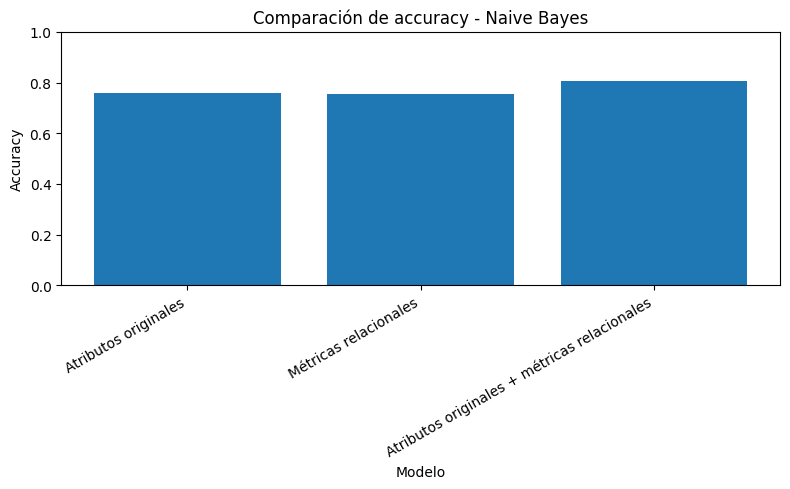

In [101]:
plt.figure(figsize=(8,5))

plt.bar(resultados_nb["modelo"], resultados_nb["accuracy"])

plt.title("Comparación de accuracy - Naive Bayes")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig("../reports/naive_bayes_comparacion_accuracy.png")
plt.show()

### Evaluación de los resultados obtenidos

Los resultados muestran diferencias claras entre los tres enfoques evaluados con Naive Bayes.

El modelo basado únicamente en los atributos originales del dataset obtiene un `accuracy` de `0.758303`. Esto indica que la información textual de los artículos permite clasificar correctamente una parte importante de los ejemplos.

El modelo basado únicamente en métricas relacionales obtiene un `accuracy` de `0.752768`. Este resultado indica que las métricas estructurales del grafo contienen información útil para aproximar la clase temática de los artículos, especialmente cuando los datos se alinean correctamente por `articulo_id`.

El mejor resultado se obtiene con el modelo combinado, que utiliza tanto los atributos originales como las métricas relacionales, alcanzando un `accuracy` de `0.806273`. Esto indica que la información relacional aporta valor adicional cuando se combina con los atributos textuales del dataset.

Por tanto, para Naive Bayes, el mejor enfoque es el modelo combinado, ya que consigue el mayor rendimiento de los tres casos analizados.

## 6. Optimización con Pipeline y GridSearchCV

Para completar la metodología vista en la práctica de `scikit-learn`, se añade una búsqueda de hiperparámetros con `GridSearchCV`.

En esta fase se optimiza el parámetro `alpha` de `CategoricalNB`, que controla el suavizado de Laplace. Además, en los modelos que utilizan métricas relacionales continuas se prueba también el número de intervalos (`n_bins`) utilizado por `KBinsDiscretizer`.

El preprocesado se incluye dentro de un `Pipeline`, de forma que durante la validación cruzada el discretizador se ajusta únicamente con los datos de entrenamiento de cada pliegue. Así se evita la fuga de datos.

In [102]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="sklearn.preprocessing._discretization"
)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.preprocessing._discretization"
)

In [103]:
def convertir_a_entero(X):
    return X.astype(int)


transformador_enteros = FunctionTransformer(convertir_a_entero)


def parametros_relevantes(busqueda):
    parametros = busqueda.best_params_.copy()
    parametros.pop("naive_bayes__min_categories", None)
    return parametros

### Optimización del modelo con atributos originales

En el caso de los atributos originales no es necesario discretizar, porque las columnas de palabras ya son binarias (`0` o `1`). Por tanto, solo se busca el mejor valor de `alpha`.

In [105]:
pipeline_palabras = Pipeline([
    ("enteros", transformador_enteros),
    ("naive_bayes", CategoricalNB(min_categories=2))
])

param_grid_palabras = {
    "naive_bayes__alpha": range(1, 11)
}

busqueda_palabras = GridSearchCV(
    pipeline_palabras,
    param_grid=param_grid_palabras,
    cv=5,
    scoring="accuracy"
)

busqueda_palabras.fit(X_train_palabras, y_train_palabras)

y_pred_palabras_opt = busqueda_palabras.predict(X_test_palabras)
accuracy_palabras_opt = accuracy_score(
    y_test_palabras,
    y_pred_palabras_opt
)

print("Mejores parámetros:", parametros_relevantes(busqueda_palabras))
print("Accuracy en validación cruzada:", busqueda_palabras.best_score_)
print("Accuracy en test:", accuracy_palabras_opt)

Mejores parámetros: {'naive_bayes__alpha': 1}
Accuracy en validación cruzada: 0.7580900586413513
Accuracy en test: 0.7583025830258303


### Optimización del modelo con métricas relacionales

En este caso las métricas continuas se discretizan dentro del `Pipeline`. La comunidad de Louvain se mantiene como variable categórica. Se prueban distintos valores de `alpha` y de `n_bins`.

In [106]:
preprocesador_metricas = ColumnTransformer(
    transformers=[
        (
            "discretizador",
            KBinsDiscretizer(
                encode="ordinal",
                strategy="quantile"
            ),
            metricas_continuas
        )
    ],
    remainder="passthrough"
)

pipeline_metricas = Pipeline([
    ("preprocesador", preprocesador_metricas),
    ("enteros", transformador_enteros),
    ("naive_bayes", CategoricalNB())
])

param_grid_metricas = []

for n_bins in [3, 4, 5, 6]:
    param_grid_metricas.append({
        "preprocesador__discretizador__n_bins": [n_bins],
        "naive_bayes__alpha": range(1, 11),
        "naive_bayes__min_categories": [
            [n_bins] * len(metricas_continuas) + [num_comunidades]
        ]
    })

busqueda_metricas = GridSearchCV(
    pipeline_metricas,
    param_grid=param_grid_metricas,
    cv=5,
    scoring="accuracy"
)

busqueda_metricas.fit(X_train_metricas, y_train_metricas)

y_pred_metricas_opt = busqueda_metricas.predict(X_test_metricas)
accuracy_metricas_opt = accuracy_score(
    y_test_metricas,
    y_pred_metricas_opt
)

print("Mejores parámetros:", parametros_relevantes(busqueda_metricas))
print("Accuracy en validación cruzada:", busqueda_metricas.best_score_)
print("Accuracy en test:", accuracy_metricas_opt)

C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sk

Mejores parámetros: {'naive_bayes__alpha': 1, 'naive_bayes__min_categories': [3, 3, 3, 3, 3, 3, 104], 'preprocesador__discretizador__n_bins': 3}
Accuracy en validación cruzada: 0.7470035440235843
Accuracy en test: 0.7509225092250923


### Optimización del modelo combinado

En el modelo combinado se mantienen las palabras binarias y la comunidad de Louvain como variables categóricas, mientras que las métricas continuas se discretizan dentro del `Pipeline`.

In [107]:
preprocesador_combinado = ColumnTransformer(
    transformers=[
        (
            "discretizador",
            KBinsDiscretizer(
                encode="ordinal",
                strategy="quantile"
            ),
            metricas_continuas
        )
    ],
    remainder="passthrough"
)

pipeline_combinado = Pipeline([
    ("preprocesador", preprocesador_combinado),
    ("enteros", transformador_enteros),
    ("naive_bayes", CategoricalNB())
])

param_grid_combinado = []

for n_bins in [3, 4, 5, 6]:
    param_grid_combinado.append({
        "preprocesador__discretizador__n_bins": [n_bins],
        "naive_bayes__alpha": range(1, 11),
        "naive_bayes__min_categories": [
            [n_bins] * len(metricas_continuas)
            + [2] * len(columnas_palabras)
            + [num_comunidades]
        ]
    })

busqueda_combinado = GridSearchCV(
    pipeline_combinado,
    param_grid=param_grid_combinado,
    cv=5,
    scoring="accuracy"
)

busqueda_combinado.fit(X_train_combinado, y_train_combinado)

y_pred_combinado_opt = busqueda_combinado.predict(X_test_combinado)
accuracy_combinado_opt = accuracy_score(
    y_test_combinado,
    y_pred_combinado_opt
)

print("Mejores parámetros:", parametros_relevantes(busqueda_combinado))
print("Accuracy en validación cruzada:", busqueda_combinado.best_score_)
print("Accuracy en test:", accuracy_combinado_opt)

C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\enriq\AppData\Roaming\Python\Python313\site-packages\sk

Mejores parámetros: {'naive_bayes__alpha': 1, 'naive_bayes__min_categories': [4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

### Comparación de modelos base y optimizados

Finalmente, comparamos los resultados obtenidos antes y después de aplicar `GridSearchCV`.

In [108]:
resultados_nb_optimizados = pd.DataFrame({
    "modelo": [
        "Atributos originales",
        "Métricas relacionales",
        "Atributos originales + métricas relacionales"
    ],
    "accuracy_base": [
        accuracy_palabras,
        accuracy_metricas,
        accuracy_combinado
    ],
    "accuracy_optimizado": [
        accuracy_palabras_opt,
        accuracy_metricas_opt,
        accuracy_combinado_opt
    ],
    "mejora": [
        accuracy_palabras_opt - accuracy_palabras,
        accuracy_metricas_opt - accuracy_metricas,
        accuracy_combinado_opt - accuracy_combinado
    ],
    "mejores_parametros": [
        parametros_relevantes(busqueda_palabras),
        parametros_relevantes(busqueda_metricas),
        parametros_relevantes(busqueda_combinado)
    ]
})

resultados_nb_optimizados

,modelo,accuracy_base,accuracy_optimizado,mejora,mejores_parametros
0,Atributos originales,0.758303,0.758303,0.000000,{'naive_bayes__alpha': 1}
1,Métricas relacionales,0.752768,0.750923,-0.001845,"{'naive_bayes__alpha': 1, 'naive_bayes__min_ca..."
2,Atributos originales + métricas relacionales,0.806273,0.804428,-0.001845,"{'naive_bayes__alpha': 1, 'naive_bayes__min_ca..."


### Interpretación de la optimización

Los resultados muestran que la optimización con `GridSearchCV` no produce una mejora clara respecto a los modelos base. En los tres casos, el mejor valor de `alpha` seleccionado es `1`, por lo que el suavizado de Laplace utilizado inicialmente ya era adecuado para este problema.

En el modelo con atributos originales, el `accuracy` se mantiene exactamente igual, pasando de `0.758303` a `0.758303`. Esto indica que la búsqueda de hiperparámetros no encuentra una configuración mejor que la inicial para las variables binarias de palabras.

En el modelo basado únicamente en métricas relacionales, el rendimiento optimizado baja ligeramente de `0.752768` a `0.750923`. La diferencia es muy pequeña (`-0.001845`), por lo que no supone un empeoramiento relevante. En este caso, `GridSearchCV` selecciona una discretización con menos intervalos (`n_bins = 3`), pero esa configuración no mejora el resultado final sobre el conjunto de prueba.

En el modelo combinado ocurre algo parecido: el `accuracy` pasa de `0.806273` a `0.804428`, también con una diferencia mínima (`-0.001845`). Aunque la validación cruzada selecciona `n_bins = 4`, el modelo base sigue obteniendo un resultado ligeramente superior en test.

Por tanto, la optimización confirma que la configuración inicial era razonable. Además, el modelo combinado continúa siendo el mejor enfoque global, ya que obtiene el mayor rendimiento tanto antes como después de aplicar `GridSearchCV`. El valor principal de esta sección es metodológico: se aplica correctamente `Pipeline` para integrar el preprocesado y se realiza la selección de hiperparámetros mediante validación cruzada sin fuga de datos.

## 7. Conclusiones 

En conclusión, el modelo combinado es el que mejor rendimiento obtiene con Naive Bayes. Las métricas relacionales por sí solas ofrecen un rendimiento parecido al de los atributos originales, y mejoran el resultado cuando se añaden a la información textual del dataset.